In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl
import itertools as it
from scipy.special import comb

import matplotlib
font = {'size'   : 11}
matplotlib.rc('font', **font)

In [8]:
#data = np.loadtxt("synthmeasures_data.txt")
data = np.loadtxt("synthmeasuresDense_data_1000.txt")
#data = np.loadtxt("synthmeasuresDense_data_100000.txt")

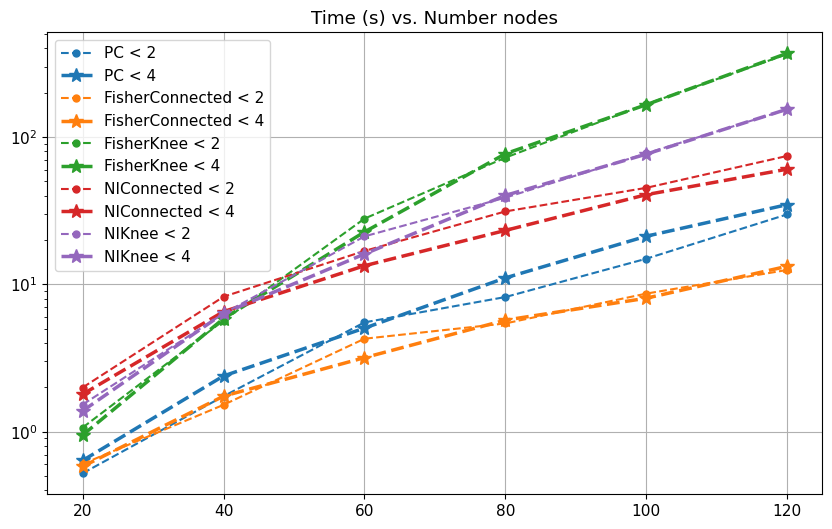

In [9]:
pl.figure(figsize=(10,6))
colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
legends=['PC', 'FisherConnected', 'FisherKnee', 'NIConnected', 'NIKnee'] 
columns=[2,8,14,20,26]
pl.plot(np.unique(data[:,0]),
        np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[columns[0]] for n_nodes in np.unique(data[:,0])]),
        '.--',color=colors[0],markersize=10,label=legends[0] + ' < 2')
pl.plot(np.unique(data[:,0]),
    np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[columns[0]] for n_nodes in np.unique(data[:,0])]),
    '*--',color=colors[0],linewidth=2.5,markersize=10,label=legends[0] + ' < 4')
for i in range(1,5):
    pl.plot(np.unique(data[:,0]),
            np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[columns[i]]
                      +np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[29+i]
                      for n_nodes in np.unique(data[:,0])]),
            '.--',color=colors[i],markersize=10,label=legends[i] + ' < 2')
    pl.plot(np.unique(data[:,0]),
        np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[columns[i]]
                  +np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[29+i]
                  for n_nodes in np.unique(data[:,0])]),
        '*--',color=colors[i],linewidth=2.5,markersize=10,label=legends[i] + ' < 4')
pl.yscale("log")
pl.title("Time (s) vs. Number nodes")
pl.grid(),pl.legend()
pl.show()

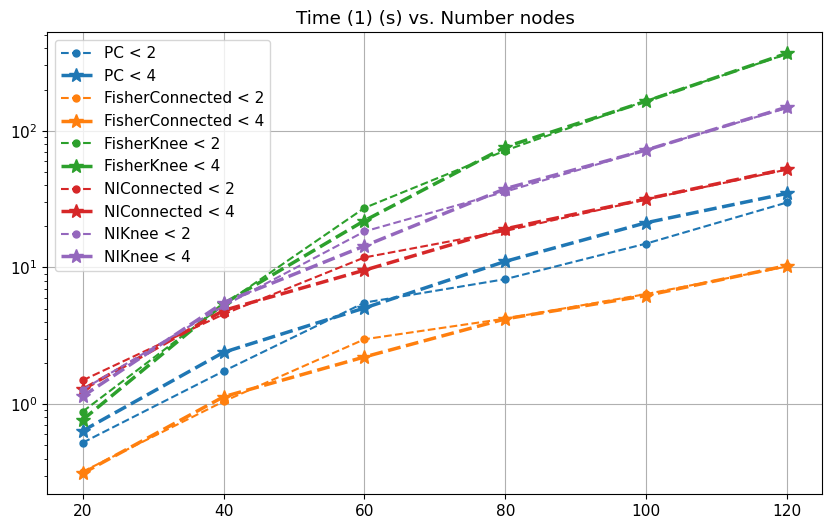

In [10]:
pl.figure(figsize=(10,6))
colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
legends=['PC', 'FisherConnected', 'FisherKnee', 'NIConnected', 'NIKnee'] 
columns=[2,8,14,20,26]
for i in range(5):
    pl.plot(np.unique(data[:,0]),
            np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[columns[i]]
                      for n_nodes in np.unique(data[:,0])]),
            '.--',color=colors[i],markersize=10,label=legends[i] + ' < 2')
    pl.plot(np.unique(data[:,0]),
        np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[columns[i]]
                  for n_nodes in np.unique(data[:,0])]),
        '*--',color=colors[i],linewidth=2.5,markersize=10,label=legends[i] + ' < 4')
pl.yscale("log")
pl.title("Time (1) (s) vs. Number nodes")
pl.grid(),pl.legend()
pl.show()

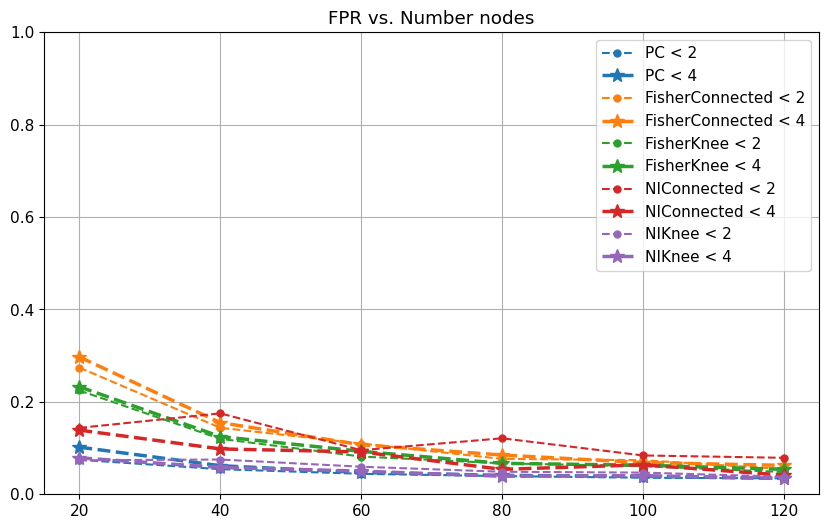

In [11]:
pl.figure(figsize=(10,6))
colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
legends=['PC', 'FisherConnected', 'FisherKnee', 'NIConnected', 'NIKnee']
columns=[3,9,15,21,27]
for i in range(5):
    pl.plot(np.unique(data[:,0]),
            np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
            '.--',color=colors[i],markersize=10,label=legends[i] + ' < 2')
    pl.plot(np.unique(data[:,0]),
        np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
        '*--',color=colors[i],linewidth=2.5,markersize=10,label=legends[i] + ' < 4')
pl.title("FPR vs. Number nodes")
pl.ylim(0,1)
pl.grid(),pl.legend()
pl.show()

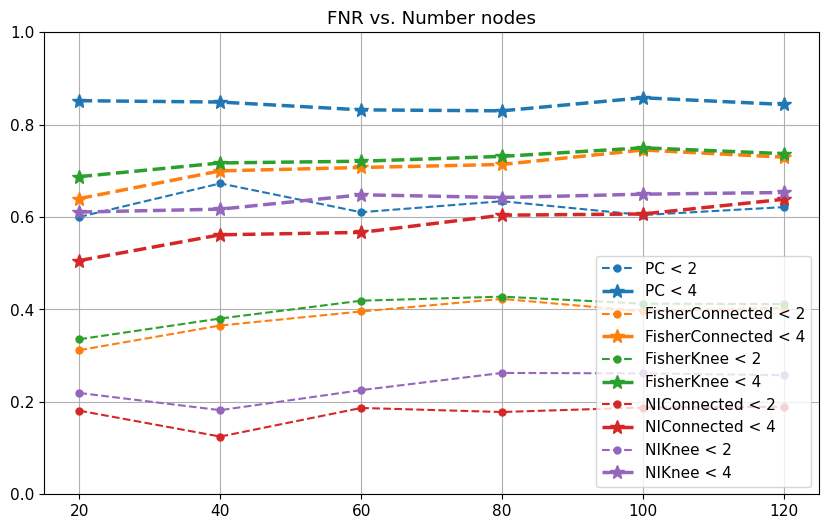

In [12]:
pl.figure(figsize=(10,6))
colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
legends=['PC', 'FisherConnected', 'FisherKnee', 'NIConnected', 'NIKnee'] 
columns=[4,10,16,22,28]
for i in range(5):
    pl.plot(np.unique(data[:,0]),
            np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
            '.--',color=colors[i],markersize=10,label=legends[i] + ' < 2')
    pl.plot(np.unique(data[:,0]),
        np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
        '*--',color=colors[i],linewidth=2.5,markersize=10,label=legends[i] + ' < 4')
pl.title("FNR vs. Number nodes")
pl.ylim(0,1)
pl.grid(),pl.legend()
pl.show()

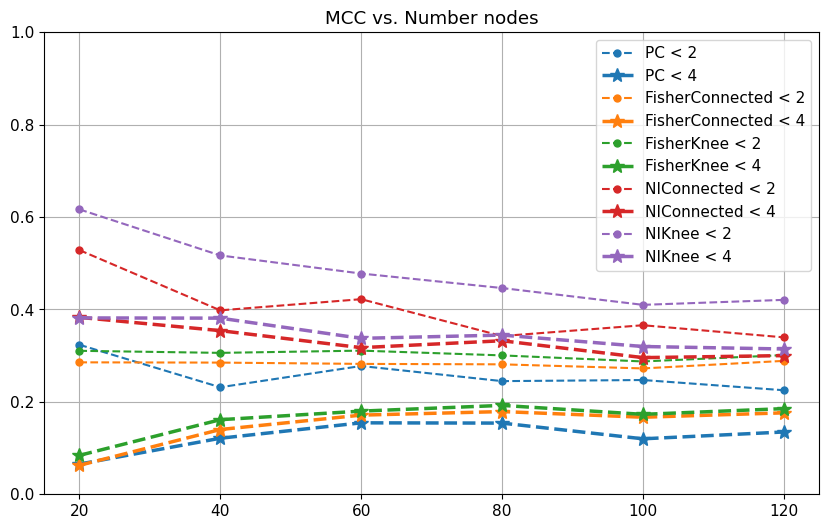

In [13]:
pl.figure(figsize=(10,6))
colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple']
columns=[5,11,17,23,29]
for i in range(5):
    pl.plot(np.unique(data[:,0]),
            np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]<2)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
            '.--',color=colors[i],markersize=10,label=legends[i] + ' < 2')
    pl.plot(np.unique(data[:,0]),
        np.array([np.mean(data[(data[:,0]==n_nodes)&(data[:,1]>2)&(data[:,1]<4)],axis=0)[columns[i]] for n_nodes in np.unique(data[:,0])]),
        '*--',color=colors[i],linewidth=2.5,markersize=10,label=legends[i] + ' < 4')
pl.title("MCC vs. Number nodes")
pl.ylim(0,1)
pl.grid(),pl.legend()
pl.show()